In [5]:
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', 'shap', 'openpyxl'], check=True)
print("All packages ready.")

All packages ready.


In [6]:
# Importing all relevant libraries
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from imblearn.over_sampling import SMOTE

import shap
shap.initjs()

warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


In [7]:
# Setting File Paths

BASE            = r'C:\Users\Shamendry\OneDrive\Final Year Project\Debtor Risk Management'
DATA_RAW        = os.path.join(BASE, 'data_raw')
DATA_PROCESSED  = os.path.join(BASE, 'data_processed')
MODEL_ARTIFACTS = os.path.join(BASE, 'model_artifacts')

os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(MODEL_ARTIFACTS, exist_ok=True)

DEBTOR_EXCEL = os.path.join(DATA_RAW, 'Debtor_Data_Anon.xlsx')
SALES_EXCEL  = os.path.join(DATA_RAW, 'Sales_Data_Anon.xlsx')

for f in [DEBTOR_EXCEL, SALES_EXCEL]:
    status = "FOUND  " if os.path.exists(f) else "MISSING"
    print(f"  {status} → {f}")


  FOUND   → C:\Users\Shamendry\OneDrive\Final Year Project\Debtor Risk Management\data_raw\Debtor_Data_Anon.xlsx
  FOUND   → C:\Users\Shamendry\OneDrive\Final Year Project\Debtor Risk Management\data_raw\Sales_Data_Anon.xlsx


In [8]:
# Converting Excel to CSV

debtor_sheets = {
    'customer_master'      : 'Customer master',
    'product_master'       : 'Product master',
    'customer_outstanding' : 'Customer Outstanding',
}

print("Converting Debtor Excel sheets to CSV...")
for csv_name, sheet_name in debtor_sheets.items():
    df_temp = pd.read_excel(DEBTOR_EXCEL, sheet_name=sheet_name)
    out_path = os.path.join(DATA_RAW, f'{csv_name}.csv')
    df_temp.to_csv(out_path, index=False)
    print(f"  Saved {csv_name}.csv  ({df_temp.shape[0]:,} rows x {df_temp.shape[1]} cols)")

print("\nConverting Sales Excel to CSV...")
df_sales_temp = pd.read_excel(SALES_EXCEL, sheet_name='Salesmaster')
df_sales_temp.to_csv(os.path.join(DATA_RAW, 'salesmaster.csv'), index=False)
print(f"  Saved salesmaster.csv  ({df_sales_temp.shape[0]:,} rows x {df_sales_temp.shape[1]} cols)")

del df_temp, df_sales_temp
print("\nDone. All Excel files converted to CSV.")

Converting Debtor Excel sheets to CSV...
  Saved customer_master.csv  (2,661 rows x 9 cols)
  Saved product_master.csv  (66,820 rows x 16 cols)
  Saved customer_outstanding.csv  (6,306 rows x 23 cols)

Converting Sales Excel to CSV...
  Saved salesmaster.csv  (1,048,575 rows x 70 cols)

Done. All Excel files converted to CSV.


In [9]:
# Loading all the CSV

outstanding_raw = pd.read_csv(os.path.join(DATA_RAW, 'customer_outstanding.csv'))
customer_master = pd.read_csv(os.path.join(DATA_RAW, 'customer_master.csv'))
product_master  = pd.read_csv(os.path.join(DATA_RAW, 'product_master.csv'))
sales_raw       = pd.read_csv(os.path.join(DATA_RAW, 'salesmaster.csv'))

print("Data loaded:")
print(f"  Customer Outstanding : {outstanding_raw.shape[0]:,} rows x {outstanding_raw.shape[1]} cols")
print(f"  Customer Master      : {customer_master.shape[0]:,} rows x {customer_master.shape[1]} cols")
print(f"  Product Master       : {product_master.shape[0]:,} rows x {product_master.shape[1]} cols")
print(f"  Sales Master         : {sales_raw.shape[0]:,} rows x {sales_raw.shape[1]} cols")

Data loaded:
  Customer Outstanding : 6,306 rows x 23 cols
  Customer Master      : 2,661 rows x 9 cols
  Product Master       : 66,820 rows x 16 cols
  Sales Master         : 1,048,575 rows x 70 cols


In [10]:
# Previewing the raw data

print("=== CUSTOMER OUTSTANDING ===")
display(outstanding_raw.head(3))

print("=== CUSTOMER MASTER ===")
display(customer_master.head(3))

print("=== SALES MASTER (first 3 rows, first 10 cols) ===")
display(sales_raw.iloc[:3, :10])


=== CUSTOMER OUTSTANDING ===


,Type,CustomerID,CusCode,CustomerName,SubLedgerCode,Term,Country,DOCID,DOCDate,Currency,...,OutstandingLKR,DueDate,OverdueDurationDays,Comments,REFBLlDate,OnboardDate,RefNo,ContractNo,CompanyCode,RBLA
0,Outstanding,13591000000260,10005,Sencha Palm Trading,10005-DCTC-USD,45 DAYS DIRECT,UNITED ARAB EMIRATES,DCTC/10008515 -Invoice,45811,USD,...,376579.8,45862.0,80,NaN,NaN,45817.0,1012791,1341220000393,DCTC,114217.36
1,Outstanding,13591000000260,10005,Sencha Palm Trading,10005-DCTC-USD,45 DAYS DIRECT,UNITED ARAB EMIRATES,DCTC/10008480 -Invoice,45799,USD,...,2409926.7,45855.0,87,NaN,NaN,45810.0,"1012689,1012690,1012692,1012693,1012699,1012708",1714440002076,DCTC,114217.36
2,Outstanding,13591000000324,10038,Darjeeling Jasmine Tea Works,10038-DCTC-USD,60 DAYS DIRECT,UNITED ARAB EMIRATES,DCTC/10008526 -Invoice,45814,USD,...,4431049.7,45878.0,64,NaN,NaN,45818.0,1012740,1379990000481,DCTC,30135.39


=== CUSTOMER MASTER ===


,CustomerId,Customer,Country,Region,CusCode,MainRegion,LMCLASSIFICATION,LocalORExport,CURRENCY
0,99999999999999,Ceylon Hibiscus Trading,GLOBAL,GLOBAL,99999,GLOBAL,NaN,A&P,USD
1,31,GreenLeaf Orchid Imports,RUSSIA,CIS,C012346,CIS,NaN,EXPORT,USD
2,13591000002018,Golden Bud Maple Tea Co.,RUSSIA,CIS,11249,CIS,NaN,EXPORT,USD


=== SALES MASTER (first 3 rows, first 10 cols) ===


,DocumentDateKey,CompanyId,Companyname,CustomerId,CusCode,CustomerClassification,Customer,Region,Country,InvoiceNo
0,20190304,13376000000094,MJF Exports (Pvt) Ltd,13591000000486,10131,01. MODERN TRADE,Matcha Lotus Beverages,ASIA,SRI LANKA,MJE/LIN005818
1,20180522,13376000000094,MJF Exports (Pvt) Ltd,13591000000486,10131,01. MODERN TRADE,Matcha Lotus Beverages,ASIA,SRI LANKA,MJE/LINV/000708
2,20190304,13376000000094,MJF Exports (Pvt) Ltd,13591000000486,10131,01. MODERN TRADE,Matcha Lotus Beverages,ASIA,SRI LANKA,MJE/LIN005818


In [11]:
# Standardising column names across the dataset
# Converting all column names to lowercase with underscores.

def clean_columns(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('-', '_'))
    return df

outstanding_raw = clean_columns(outstanding_raw)
customer_master = clean_columns(customer_master)
product_master  = clean_columns(product_master)
sales_raw       = clean_columns(sales_raw)

print("Customer Outstanding columns:")
print(outstanding_raw.columns.tolist())
print("\nCustomer Master columns:")
print(customer_master.columns.tolist())


Customer Outstanding columns:
['type', 'customerid', 'cuscode', 'customername', 'subledgercode', 'term', 'country', 'docid', 'docdate', 'currency', 'outstandingnative', 'usdexrate', 'outstandingusd', 'outstandinglkr', 'duedate', 'overduedurationdays', 'comments', 'refblldate', 'onboarddate', 'refno', 'contractno', 'companycode', 'rbla']

Customer Master columns:
['customerid', 'customer', 'country', 'region', 'cuscode', 'mainregion', 'lmclassification', 'localorexport', 'currency']


In [12]:
# Extracting document typefrom the DOCID column
# The DOCID column encodes the document type after the "-"

outstanding_raw['document_type'] = (
    outstanding_raw['docid']
    .str.split('-')
    .str[-1]
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print("Document type counts (before any cleaning):")
print(outstanding_raw['document_type'].value_counts())

Document type counts (before any cleaning):
document_type
invoice        5334
receipt         776
debit_note      115
credit_note      81
Name: count, dtype: int64


In [13]:
# Fixing dates in the Debtor Data
# Dates in the Customer Outstanding sheet are stored as Excel

def fix_excel_serial_date(series):
    def convert_one(val):
        try:
            val = float(val)
            if val > 0:
                return pd.to_datetime(val, unit='D', origin='1899-12-30')
            return pd.NaT
        except:
            return pd.NaT
    return series.apply(convert_one)

outstanding_raw['docdate'] = fix_excel_serial_date(outstanding_raw['docdate'])
outstanding_raw['duedate'] = fix_excel_serial_date(outstanding_raw['duedate'])

if 'onboarddate' in outstanding_raw.columns:
    outstanding_raw['onboarddate'] = fix_excel_serial_date(outstanding_raw['onboarddate'])

print("Date columns after conversion:")
print(outstanding_raw[['docid', 'docdate', 'duedate']].head(8).to_string())

Date columns after conversion:
                    docid    docdate    duedate
0  DCTC/10008515 -Invoice 2025-06-03 2025-07-24
1  DCTC/10008480 -Invoice 2025-05-22 2025-07-17
2  DCTC/10008526 -Invoice 2025-06-06 2025-08-09
3  DCTC/10007863 -Invoice 2024-11-28 2025-02-11
4  DCTC/10008143 -Invoice 2025-02-11 2025-04-28
5  DCTC/10007957 -Invoice 2024-12-20 2025-03-09
6  DCTC/10008448 -Invoice 2025-05-09 2025-07-30
7  DCTC/10008870 -Invoice 2025-09-22 2025-12-06


In [14]:
# Casting Customer ID to string for consistent joining
# CustomerID is stored as a large integer that can lose precision

outstanding_raw['customerid'] = outstanding_raw['customerid'].astype(str).str.strip()
outstanding_raw['cuscode']    = outstanding_raw['cuscode'].astype(str).str.strip()

customer_master['customerid'] = customer_master['customerid'].astype(str).str.strip()
if 'cuscode' in customer_master.columns:
    customer_master['cuscode'] = customer_master['cuscode'].astype(str).str.strip()

sales_raw['customerid'] = sales_raw['customerid'].astype(str).str.strip()
sales_raw['cuscode']    = sales_raw['cuscode'].astype(str).str.strip()

print("Customer ID types confirmed as string.")
print(f"Outstanding unique customers : {outstanding_raw['customerid'].nunique():,}")
print(f"Customer master unique        : {customer_master['customerid'].nunique():,}")
print(f"Sales unique customers        : {sales_raw['customerid'].nunique():,}")


Customer ID types confirmed as string.
Outstanding unique customers : 835
Customer master unique        : 2,661
Sales unique customers        : 1,639


In [15]:
# Removing ERP migrated data
# When migrated to their current ERP, bulk adjustment entries were created all on the same day (~March 2021, Excel serial 44286) with exactly 1,656 overdue days.
# These are NOT real transactions. They are opening balance carry-forwards that distort all overdue calculations.
# Removing write-off debit notes (RefNo = "WO") which are debts already declared unrecoverable by the finance team.

rows_before = len(outstanding_raw)

# Migration entries: same ERP cutover date AND 1656 overdue days
migration_mask = (
    outstanding_raw['docdate'].dt.date == pd.Timestamp('2021-03-05').date()
) & (outstanding_raw['overduedurationdays'] == 1656)

print(f"Migration entries found   : {migration_mask.sum()}")
print(f"Customers affected        : {outstanding_raw[migration_mask]['customerid'].nunique()}")

debtor_df = outstanding_raw[~migration_mask].copy()

# Write-off debit notes
wo_mask = (
    (debtor_df['document_type'] == 'debit_note') &
    (debtor_df['refno'].astype(str).str.strip().str.upper() == 'WO')
)
print(f"Write-off debit notes     : {wo_mask.sum()}")

debtor_df = debtor_df[~wo_mask].copy()

print(f"\nRows before cleaning      : {rows_before:,}")
print(f"Rows after cleaning       : {len(debtor_df):,}")
print(f"Total rows removed        : {rows_before - len(debtor_df):,}")

Migration entries found   : 0
Customers affected        : 0
Write-off debit notes     : 2

Rows before cleaning      : 6,306
Rows after cleaning       : 6,304
Total rows removed        : 2


In [16]:
# Seperating the document types

invoices     = debtor_df[debtor_df['document_type'] == 'invoice'].copy()
receipts     = debtor_df[debtor_df['document_type'] == 'receipt'].copy()
debit_notes  = debtor_df[debtor_df['document_type'] == 'debit_note'].copy()
credit_notes = debtor_df[debtor_df['document_type'] == 'credit_note'].copy()

print("Document type counts after cleaning:")
print(f"  Invoices     : {len(invoices):,}")
print(f"  Receipts     : {len(receipts):,}")
print(f"  Debit Notes  : {len(debit_notes):,}")
print(f"  Credit Notes : {len(credit_notes):,}")

Document type counts after cleaning:
  Invoices     : 5,334
  Receipts     : 776
  Debit Notes  : 113
  Credit Notes : 81


In [17]:
# Building Invoice Features Per Customer

invoice_features = invoices.groupby('customerid').agg(
    cuscode               = ('cuscode',             'first'),
    invoice_count         = ('docid',               'count'),
    total_outstanding_usd = ('outstandingusd',       'sum'),
    total_outstanding_lkr = ('outstandinglkr',       'sum'),
    avg_overdue_days      = ('overduedurationdays',   'mean'),
    max_overdue_days      = ('overduedurationdays',   'max'),
    num_overdue_invoices  = ('overduedurationdays',   lambda x: (x > 0).sum()),
    pct_overdue_invoices  = ('overduedurationdays',   lambda x: round((x > 0).mean(), 4)),
    avg_invoice_value_usd = ('outstandingusd',        'mean'),
).reset_index()

_aging = invoices.copy()
_aging['age_band'] = pd.cut(
    _aging['overduedurationdays'],
    bins=[-1, 30, 60, 90, float('inf')],
    labels=['0_30', '31_60', '61_90', '91_plus']
)
_aging_pivot = _aging.pivot_table(
    index='customerid',
    columns='age_band',
    values='outstandingusd',
    aggfunc='sum',
    fill_value=0
).reset_index()
_aging_pivot.columns = (
    ['customerid'] + [f'outstanding_{c}' for c in _aging_pivot.columns[1:]]
)
invoice_features = invoice_features.merge(_aging_pivot, on='customerid', how='left')
for _col in ['outstanding_0_30', 'outstanding_31_60',
             'outstanding_61_90', 'outstanding_91_plus']:
    if _col not in invoice_features.columns:
        invoice_features[_col] = 0.0
    invoice_features[_col] = invoice_features[_col].fillna(0)

print("Invoice features shape:", invoice_features.shape)
display(invoice_features.head())

Invoice features shape: (656, 14)


,customerid,cuscode,invoice_count,total_outstanding_usd,total_outstanding_lkr,avg_overdue_days,max_overdue_days,num_overdue_invoices,pct_overdue_invoices,avg_invoice_value_usd,outstanding_0_30,outstanding_31_60,outstanding_61_90,outstanding_91_plus
0,1002010000765,12856,2,938.913729,280000.0,22.50,45,1,0.50,469.456865,563.235412,375.678317,0.000000,0.000000
1,1002880000733,12874,2,1377.782043,410640.0,11.50,23,1,0.50,688.891021,1377.782043,0.000000,0.000000,0.000000
2,10031000009075,12275,20,15087.481799,4498753.0,6.95,23,11,0.55,754.374090,15087.481799,0.000000,0.000000,0.000000
3,10032000007593,12702,3,563.019884,167078.3,90.00,114,3,1.00,187.673295,0.000000,0.000000,433.012585,130.007298
4,10048000003503,12343,2,185.500000,58385.3,673.00,772,2,1.00,92.750000,0.000000,0.000000,0.000000,185.500000


In [18]:
# Building Receipt Features Per Customer

receipt_features = receipts.groupby('customerid').agg(
    receipt_count         = ('docid',             'count'),
    total_unapplied_credit= ('outstandingnative',  'sum'),
).reset_index()

receipt_features['has_unapplied_receipt'] = 1
receipt_features['unapplied_credit_abs']  = receipt_features['total_unapplied_credit'].abs()
receipt_features = receipt_features.drop(columns=['total_unapplied_credit'])

print("Receipt features shape:", receipt_features.shape)
display(receipt_features.head())

Receipt features shape: (383, 4)


,customerid,receipt_count,has_unapplied_receipt,unapplied_credit_abs
0,10031000009075,2,1,250000.00
1,10032000007593,1,1,100000.00
2,1020110002456,1,1,15395.00
3,10271000007704,2,1,46860.00
4,10305000000020,4,1,912346.37


In [19]:
# Building Debit Note Features Per Customer

debit_features = debit_notes.groupby('customerid').agg(
    debit_note_count     = ('docid',          'count'),
    total_debit_note_usd = ('outstandingusd', 'sum'),
).reset_index()

print("Debit note features shape:", debit_features.shape)
display(debit_features.head())

Debit note features shape: (50, 3)


,customerid,debit_note_count,total_debit_note_usd
0,11980000004680,1,5000.844313
1,11980000005091,13,51185.650000
2,12102000001530,1,600.000000
3,12799000003587,4,-100.702768
4,13335000001460,3,1084.373143


In [20]:
# CBuilding Credit Note Features Per Customer

credit_features = credit_notes.groupby('customerid').agg(
    credit_note_count     = ('docid',          'count'),
    total_credit_note_usd = ('outstandingusd', 'sum'),
).reset_index()

print("Credit note features shape:", credit_features.shape)
display(credit_features.head())

Credit note features shape: (51, 3)


,customerid,credit_note_count,total_credit_note_usd
0,11287000004415,2,-24.26775
1,11945000001824,1,-243.60000
2,12102000001530,1,-887.92000
3,12217000000060,1,-302.25000
4,13591000000274,1,-1897.63000


In [21]:
# Merging all Debtor Features into One Table

master_debtor = invoice_features.copy()

master_debtor = master_debtor.merge(
    receipt_features[['customerid', 'receipt_count',
                      'unapplied_credit_abs', 'has_unapplied_receipt']],
    on='customerid', how='left'
)
master_debtor = master_debtor.merge(debit_features,  on='customerid', how='left')
master_debtor = master_debtor.merge(credit_features, on='customerid', how='left')

fill_zero_cols = [
    'receipt_count', 'unapplied_credit_abs', 'has_unapplied_receipt',
    'debit_note_count', 'total_debit_note_usd',
    'credit_note_count', 'total_credit_note_usd'
]
master_debtor[fill_zero_cols] = master_debtor[fill_zero_cols].fillna(0)

master_debtor['receipt_to_invoice_ratio'] = (
    master_debtor['receipt_count'] /
    master_debtor['invoice_count'].replace(0, np.nan)
).fillna(0)

print("Master debtor feature table shape:", master_debtor.shape)
display(master_debtor.head())
print("\nMissing values:")
print(master_debtor.isnull().sum())

Master debtor feature table shape: (656, 22)


,customerid,cuscode,invoice_count,total_outstanding_usd,total_outstanding_lkr,avg_overdue_days,max_overdue_days,num_overdue_invoices,pct_overdue_invoices,avg_invoice_value_usd,...,outstanding_61_90,outstanding_91_plus,receipt_count,unapplied_credit_abs,has_unapplied_receipt,debit_note_count,total_debit_note_usd,credit_note_count,total_credit_note_usd,receipt_to_invoice_ratio
0,1002010000765,12856,2,938.913729,280000.0,22.50,45,1,0.50,469.456865,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,1002880000733,12874,2,1377.782043,410640.0,11.50,23,1,0.50,688.891021,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,10031000009075,12275,20,15087.481799,4498753.0,6.95,23,11,0.55,754.374090,...,0.000000,0.000000,2.0,250000.0,1.0,0.0,0.0,0.0,0.0,0.100000
3,10032000007593,12702,3,563.019884,167078.3,90.00,114,3,1.00,187.673295,...,433.012585,130.007298,1.0,100000.0,1.0,0.0,0.0,0.0,0.0,0.333333
4,10048000003503,12343,2,185.500000,58385.3,673.00,772,2,1.00,92.750000,...,0.000000,185.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000



Missing values:
customerid                  0
cuscode                     0
invoice_count               0
total_outstanding_usd       0
total_outstanding_lkr       0
avg_overdue_days            0
max_overdue_days            0
num_overdue_invoices        0
pct_overdue_invoices        0
avg_invoice_value_usd       0
outstanding_0_30            0
outstanding_31_60           0
outstanding_61_90           0
outstanding_91_plus         0
receipt_count               0
unapplied_credit_abs        0
has_unapplied_receipt       0
debit_note_count            0
total_debit_note_usd        0
credit_note_count           0
total_credit_note_usd       0
receipt_to_invoice_ratio    0
dtype: int64


In [22]:
# Merging Customer Info from Customer Master

print("Customer master columns available:")
print(customer_master.columns.tolist())

Customer master columns available:
['customerid', 'customer', 'country', 'region', 'cuscode', 'mainregion', 'lmclassification', 'localorexport', 'currency']


In [23]:
# Joining Customer Master into Debtor Table

cust_cols_available = customer_master.columns.tolist()
keep_cols = ['customerid']

for possible in ['customername', 'customer', 'name', 'country',
                 'term', 'creditlimit', 'credit_limit',
                 'customerclassification', 'customer_classification']:
    if possible in cust_cols_available:
        keep_cols.append(possible)

cust_info = customer_master[keep_cols].drop_duplicates('customerid')
master_debtor = master_debtor.merge(cust_info, on='customerid', how='left')

print("Master debtor with customer info shape:", master_debtor.shape)
display(master_debtor.head())

Master debtor with customer info shape: (656, 24)


,customerid,cuscode,invoice_count,total_outstanding_usd,total_outstanding_lkr,avg_overdue_days,max_overdue_days,num_overdue_invoices,pct_overdue_invoices,avg_invoice_value_usd,...,receipt_count,unapplied_credit_abs,has_unapplied_receipt,debit_note_count,total_debit_note_usd,credit_note_count,total_credit_note_usd,receipt_to_invoice_ratio,customer,country
0,1002010000765,12856,2,938.913729,280000.0,22.50,45,1,0.50,469.456865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,Darjeeling Cedar Exports 3E9,SRI LANKA
1,1002880000733,12874,2,1377.782043,410640.0,11.50,23,1,0.50,688.891021,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,Oolong Ivy Imports,SRI LANKA
2,10031000009075,12275,20,15087.481799,4498753.0,6.95,23,11,0.55,754.374090,...,2.0,250000.0,1.0,0.0,0.0,0.0,0.0,0.100000,Matcha Sage Distributors 829,SRI LANKA
3,10032000007593,12702,3,563.019884,167078.3,90.00,114,3,1.00,187.673295,...,1.0,100000.0,1.0,0.0,0.0,0.0,0.0,0.333333,Sencha Bamboo Tea Co. AEF,SRI LANKA
4,10048000003503,12343,2,185.500000,58385.3,673.00,772,2,1.00,92.750000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,Herbal Sage Imports,KAZAKHSTAN


In [24]:
# Cleaning Sales Data
sales_raw['invoicedate'] = pd.to_datetime(sales_raw['invoicedate'], errors='coerce')

# Picking the best available sales value column
SALES_VALUE_COL = None
for col in ['fobvalue', 'netamount', 'lkrvalue', 'valuert']:
    if col in sales_raw.columns:
        SALES_VALUE_COL = col
        break

print(f"Sales value column selected: '{SALES_VALUE_COL}'")

# Checking the columns that exist  
want_cols = ['customerid', 'cuscode', 'customer', 'customerclassification',
             'region', 'country', 'invoiceno', 'invoicedate', 'productid',
             'productcode', 'productgroup', 'brand', 'subbrand', 'range',
             SALES_VALUE_COL]
keep_sales = [c for c in want_cols if c in sales_raw.columns]

sales_clean = sales_raw[keep_sales].copy()
sales_clean = sales_clean.rename(columns={SALES_VALUE_COL: 'sales_value'})

sales_clean = sales_clean[
    sales_clean['invoicedate'].notna() &
    (sales_clean['sales_value'] > 0)
].copy()

# Casting product ID to string
if 'productid' in sales_clean.columns:
    sales_clean['productid'] = sales_clean['productid'].astype(str).str.strip()

print(f"\nSales rows after cleaning : {sales_clean.shape[0]:,}")
print(f"Date range                : "
      f"{sales_clean['invoicedate'].min().date()} to "
      f"{sales_clean['invoicedate'].max().date()}")
display(sales_clean.head(3))

Sales value column selected: 'fobvalue'

Sales rows after cleaning : 457,548
Date range                : 2018-04-04 to 2026-01-20


,customerid,cuscode,customer,customerclassification,region,country,invoiceno,invoicedate,productid,productcode,productgroup,brand,subbrand,range,sales_value
0,13591000000486,10131,Matcha Lotus Beverages,01. MODERN TRADE,ASIA,SRI LANKA,MJE/LIN005818,2019-03-04,13758000003850,80440-012-R00-SRL-LMK-0020FE-1.5G-RH,RETAIL,DILMAH,DILMAH LOCAL MARKET,HERBAL INFUSIONS,2536.27
1,13591000000486,10131,Matcha Lotus Beverages,01. MODERN TRADE,ASIA,SRI LANKA,MJE/LINV/000708,2018-05-22,13758000005990,80434-012-R00-SRL-LMK-0020FE-1.5G-PM,RETAIL,DILMAH,DILMAH LOCAL MARKET,HERBAL INFUSIONS,2536.27
2,13591000000486,10131,Matcha Lotus Beverages,01. MODERN TRADE,ASIA,SRI LANKA,MJE/LIN005818,2019-03-04,13758000005990,80434-012-R00-SRL-LMK-0020FE-1.5G-PM,RETAIL,DILMAH,DILMAH LOCAL MARKET,HERBAL INFUSIONS,2536.27


In [25]:
# Joining Product Master to Sales Data

# Identifying product ID and category columns in product master
pid_col = None
for col in ['productid', 'product_id', 'productcode']:
    if col in product_master.columns:
        pid_col = col
        break

# Prefering productgroup as the category — fall back to brand or range
cat_col = None
for col in ['productgroup', 'product_group', 'brand', 'range', 'category']:
    if col in product_master.columns:
        cat_col = col
        break

print(f"Product master ID column       : {pid_col}")
print(f"Product master category column : {cat_col}")

if pid_col and cat_col:
    product_master[pid_col] = product_master[pid_col].astype(str).str.strip()

    # Selecting useful product reference columns
    prod_ref_cols = [pid_col]
    for col in ['productgroup', 'brand', 'subbrand', 'range', 'product']:
        if col in product_master.columns and col != pid_col:
            prod_ref_cols.append(col)

    product_ref = product_master[prod_ref_cols].drop_duplicates(pid_col)

    # Joining onto sales
    sales_clean = sales_clean.merge(
        product_ref,
        left_on='productid',
        right_on=pid_col,
        how='left',
        suffixes=('', '_pm')  # _pm = from product master, avoids col clashes
    )

    # Using productgroup as the main category label
    if 'productgroup' in sales_clean.columns:
        sales_clean['product_category'] = sales_clean['productgroup']
    elif 'brand' in sales_clean.columns:
        sales_clean['product_category'] = sales_clean['brand']
    else:
        sales_clean['product_category'] = 'Unknown'

    print(f"\nTop 10 product categories in sales data:")
    print(sales_clean['product_category'].value_counts().head(10))
    print(f"\nSales rows with category matched: "
          f"{sales_clean['product_category'].notna().sum():,} / {len(sales_clean):,}")
else:
    sales_clean['product_category'] = 'Unknown'
    print("Could not find product columns — product_category set to Unknown")

Product master ID column       : productid
Product master category column : productgroup

Top 10 product categories in sales data:
product_category
RETAIL          278479
GLOBAL          100756
FOOD SERVICE     78079
BULK               177
Name: count, dtype: int64

Sales rows with category matched: 457,491 / 457,548


In [26]:
# Building Sales Behaviour Features Per Customer
# Summarising years of sales history into one row per customer.

SNAPSHOT_DATE = pd.Timestamp('2026-01-20')

behaviour_df = sales_clean.groupby('customerid').agg(
    cuscode             = ('cuscode',           'first'),
    customer            = ('customer',          'first'),
    total_sales_value   = ('sales_value',        'sum'),
    avg_invoice_value   = ('sales_value',        'mean'),
    invoice_count       = ('invoiceno',          'nunique'),
    active_months       = ('invoicedate',        lambda x: x.dt.to_period('M').nunique()),
    first_purchase      = ('invoicedate',        'min'),
    last_purchase       = ('invoicedate',        'max'),
    unique_products     = ('productid',          'nunique'),
    unique_categories   = ('product_category',   'nunique'),
    top_category        = ('product_category',   lambda x: x.mode().iloc[0]
                                                  if len(x.dropna()) > 0
                                                  else 'Unknown'),
).reset_index()

# How long have they been a customer
behaviour_df['relationship_years'] = (
    (behaviour_df['last_purchase'] - behaviour_df['first_purchase'])
    .dt.days / 365.25
).round(2)

# Days since last purchase from snapshot date
behaviour_df['recency_days'] = (
    SNAPSHOT_DATE - behaviour_df['last_purchase']
).dt.days

# Average invoices per active month
behaviour_df['purchase_frequency'] = (
    behaviour_df['invoice_count'] /
    behaviour_df['active_months'].replace(0, np.nan)
).fillna(0).round(3)

# Category concentration: 1.0 = buys only one category (low diversity)
# Lower value = buys across many categories = deeper relationship
behaviour_df['category_concentration'] = (
    1 / behaviour_df['unique_categories'].replace(0, np.nan)
).fillna(1).round(4)

print("Sales behaviour features shape:", behaviour_df.shape)
print("\nNew product-based features added:")
print(behaviour_df[['customerid', 'unique_products',
                     'unique_categories', 'top_category',
                     'category_concentration']].head(8).to_string())

Sales behaviour features shape: (1622, 16)

New product-based features added:
       customerid  unique_products  unique_categories top_category  category_concentration
0  10010000001151                4                  1       GLOBAL                     1.0
1   1002010000765                1                  1       GLOBAL                     1.0
2  10022000000339               17                  1       GLOBAL                     1.0
3   1002880000733                1                  1       GLOBAL                     1.0
4  10031000009075              111                  2       RETAIL                     0.5
5  10032000007593                2                  1       GLOBAL                     1.0
6  10048000003503               21                  2       RETAIL                     0.5
7   1005990000065                3                  1         BULK                     1.0


In [27]:
# Scaling Sales Features Before Clustering

cluster_feature_cols = [
    'total_sales_value', 'avg_invoice_value', 'invoice_count',
    'active_months', 'relationship_years', 'recency_days',
    'purchase_frequency', 'unique_products',
    'unique_categories',        # how many product groups they buy from
    'category_concentration'    # how concentrated vs spread their buying is
]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(behaviour_df[cluster_feature_cols])

print("Scaled clustering matrix shape:", X_cluster.shape)
print("\nMean of each scaled feature (should all be ~0):")
print(pd.DataFrame(X_cluster, columns=cluster_feature_cols).mean().round(4))

Scaled clustering matrix shape: (1622, 10)

Mean of each scaled feature (should all be ~0):
total_sales_value        -0.0
avg_invoice_value         0.0
invoice_count            -0.0
active_months            -0.0
relationship_years        0.0
recency_days              0.0
purchase_frequency        0.0
unique_products           0.0
unique_categories         0.0
category_concentration    0.0
dtype: float64


  k=2  inertia=12232.1
  k=3  inertia=9226.6
  k=4  inertia=7905.7
  k=5  inertia=6927.6
  k=6  inertia=5539.4
  k=7  inertia=4460.1
  k=8  inertia=3689.0
  k=9  inertia=3033.9
  k=10  inertia=2725.2


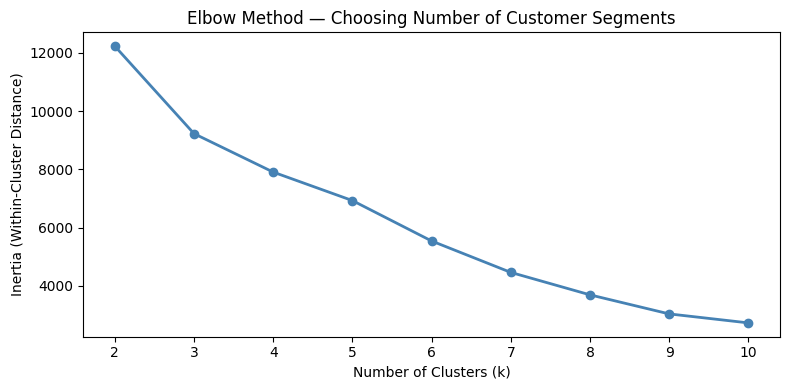

In [28]:
# Elbow Method: Finding the right number of clusters

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia_values.append(km.inertia_)
    print(f"  k={k}  inertia={km.inertia_:.1f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertia_values, marker='o',
         color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Distance)')
plt.title('Elbow Method — Choosing Number of Customer Segments')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'elbow_plot.png'), dpi=150)
plt.show()

  k=2  silhouette=0.4358
  k=3  silhouette=0.4273
  k=4  silhouette=0.3297
  k=5  silhouette=0.3443
  k=6  silhouette=0.3397
  k=7  silhouette=0.3698
  k=8  silhouette=0.3781
  k=9  silhouette=0.3945
  k=10  silhouette=0.4005


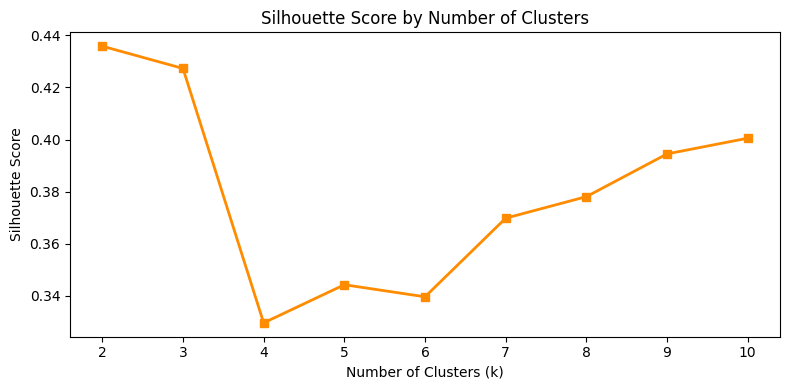

In [29]:
# Silhouette scores to validate cluster choice

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    sil_scores.append(sil)
    print(f"  k={k}  silhouette={sil:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_scores, marker='s',
         color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'silhouette_plot.png'), dpi=150)
plt.show()


In [30]:
# Fit K-Means with k=5 and profile each cluster

K_CHOSEN     = 5
kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
behaviour_df['behaviour_cluster'] = kmeans_final.fit_predict(X_cluster)

print("Cluster size distribution:")
print(behaviour_df['behaviour_cluster'].value_counts().sort_index())

print("\nCluster profiles (mean values per cluster):")
cluster_profile = behaviour_df.groupby(
    'behaviour_cluster')[cluster_feature_cols].mean().round(1)
display(cluster_profile)

Cluster size distribution:
behaviour_cluster
0     14
1    831
2      1
3    339
4    437
Name: count, dtype: int64

Cluster profiles (mean values per cluster):


,total_sales_value,avg_invoice_value,invoice_count,active_months,relationship_years,recency_days,purchase_frequency,unique_products,unique_categories,category_concentration
behaviour_cluster,,,,,,,,,,
0,412307271.5,30723.5,1455.1,75.9,6.6,167.8,18.6,471.3,2.6,0.4
1,728209.1,190695.0,4.5,3.1,0.7,1267.1,1.3,6.5,1.0,1.0
2,669599982.1,8547.5,13938.0,91.0,7.4,102.0,153.2,94.0,3.0,0.3
3,5517678.7,83816.8,44.0,23.9,5.7,278.4,1.5,23.7,1.0,1.0
4,4151234.0,20104.6,64.5,29.4,4.7,368.1,1.8,44.6,2.3,0.4


In [31]:
# DIAGNOSTIC — See full cluster profiles before naming

print("Full cluster profiles:")
display(behaviour_df.groupby('behaviour_cluster')[[
    'total_sales_value', 'avg_invoice_value', 'invoice_count',
    'active_months', 'relationship_years', 'recency_days',
    'purchase_frequency', 'unique_products', 'unique_categories'
]].mean().round(2))

print("\nCluster sizes:")
print(behaviour_df['behaviour_cluster'].value_counts().sort_index())

Full cluster profiles:


,total_sales_value,avg_invoice_value,invoice_count,active_months,relationship_years,recency_days,purchase_frequency,unique_products,unique_categories
behaviour_cluster,,,,,,,,,
0,4.123073e+08,30723.52,1455.14,75.93,6.56,167.79,18.62,471.29,2.64
1,7.282091e+05,190695.00,4.47,3.07,0.69,1267.15,1.25,6.53,1.04
2,6.696000e+08,8547.47,13938.00,91.00,7.45,102.00,153.16,94.00,3.00
3,5.517679e+06,83816.79,43.99,23.95,5.67,278.41,1.49,23.74,1.00
4,4.151234e+06,20104.62,64.52,29.40,4.69,368.11,1.79,44.63,2.35



Cluster sizes:
behaviour_cluster
0     14
1    831
2      1
3    339
4    437
Name: count, dtype: int64


In [32]:
# Assigning names to each cluster

cluster_name_map = {
    0: 'Loyal Medium Buyers',     # moderate sales, long relationship, consistent
    1: 'High Frequency Buyers',   # many invoices, diverse products, high frequency
    2: 'Churned / Inactive',      # last purchased ~3.5 years ago, briefly active
    3: 'Strategic High-Value',    # massive sales, extremely high frequency
    4: 'High Value One-Off',      # huge single invoices but stopped buying
}

behaviour_df['cluster_name'] = behaviour_df['behaviour_cluster'].map(cluster_name_map)

print("Final cluster names and counts:")
print(behaviour_df['cluster_name'].value_counts())

print("\nProduct diversity by cluster:")
print(behaviour_df.groupby('cluster_name')[[
    'unique_products', 'unique_categories', 'category_concentration'
]].mean().round(2).to_string())

Final cluster names and counts:
cluster_name
High Frequency Buyers    831
High Value One-Off       437
Strategic High-Value     339
Loyal Medium Buyers       14
Churned / Inactive         1
Name: count, dtype: int64

Product diversity by cluster:
                       unique_products  unique_categories  category_concentration
cluster_name                                                                     
Churned / Inactive               94.00               3.00                    0.33
High Frequency Buyers             6.53               1.04                    0.98
High Value One-Off               44.63               2.35                    0.44
Loyal Medium Buyers             471.29               2.64                    0.45
Strategic High-Value             23.74               1.00                    1.00


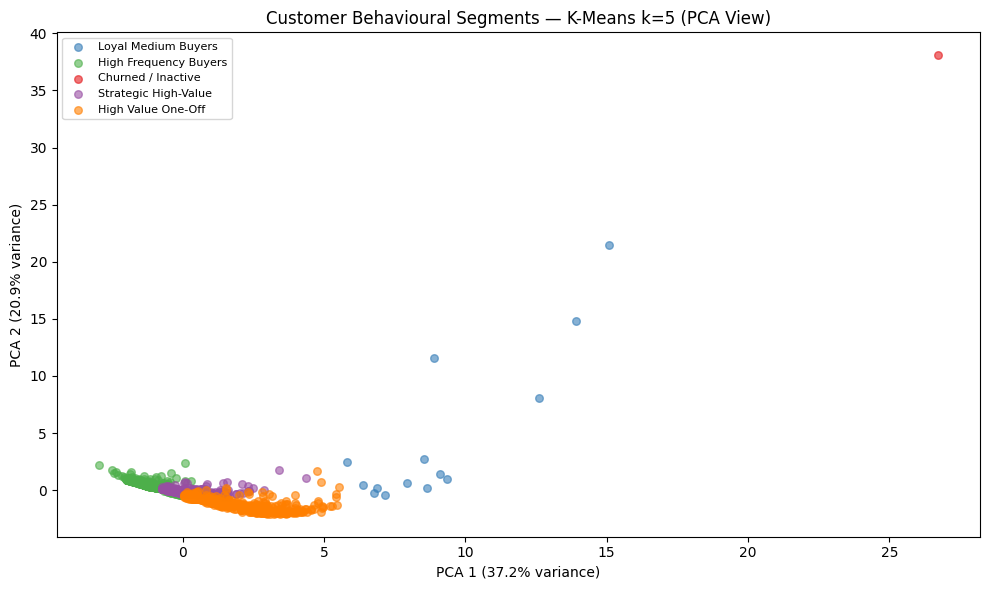

In [33]:
# Visualising Cluster with PCA
# The percentage labels show how much variance each axis explains.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
behaviour_df['pca_x'] = X_pca[:, 0]
behaviour_df['pca_y'] = X_pca[:, 1]

colors = ['#377eb8', '#4daf4a', '#e41a1c', '#984ea3', '#ff7f00']
plt.figure(figsize=(10, 6))
for i, (cluster_id, cluster_label) in enumerate(cluster_name_map.items()):
    mask = behaviour_df['behaviour_cluster'] == cluster_id
    plt.scatter(
        behaviour_df.loc[mask, 'pca_x'],
        behaviour_df.loc[mask, 'pca_y'],
        label=cluster_label,
        alpha=0.6, s=30,
        color=colors[i % len(colors)]
    )
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Behavioural Segments — K-Means k=5 (PCA View)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'cluster_pca_plot.png'), dpi=150)
plt.show()

In [34]:
# Building the Master Modelling Dataset

model_df = master_debtor.merge(
    behaviour_df[[
        'customerid', 'behaviour_cluster', 'cluster_name',
        'total_sales_value', 'avg_invoice_value', 'active_months',
        'recency_days', 'purchase_frequency', 'relationship_years',
        'unique_products', 'unique_categories',
        'category_concentration', 'top_category'
    ]],
    on='customerid', how='left'
)

sales_fill_cols = [
    'behaviour_cluster', 'total_sales_value', 'avg_invoice_value',
    'active_months', 'recency_days', 'purchase_frequency',
    'relationship_years', 'unique_products',
    'unique_categories', 'category_concentration'
]
model_df[sales_fill_cols] = model_df[sales_fill_cols].fillna(0)
model_df['cluster_name'] = model_df['cluster_name'].fillna('No Sales History')
model_df['top_category'] = model_df['top_category'].fillna('Unknown')

print("Master modelling dataset shape:", model_df.shape)
print("\nAll columns:")
print(model_df.columns.tolist())

Master modelling dataset shape: (656, 36)

All columns:
['customerid', 'cuscode', 'invoice_count', 'total_outstanding_usd', 'total_outstanding_lkr', 'avg_overdue_days', 'max_overdue_days', 'num_overdue_invoices', 'pct_overdue_invoices', 'avg_invoice_value_usd', 'outstanding_0_30', 'outstanding_31_60', 'outstanding_61_90', 'outstanding_91_plus', 'receipt_count', 'unapplied_credit_abs', 'has_unapplied_receipt', 'debit_note_count', 'total_debit_note_usd', 'credit_note_count', 'total_credit_note_usd', 'receipt_to_invoice_ratio', 'customer', 'country', 'behaviour_cluster', 'cluster_name', 'total_sales_value', 'avg_invoice_value', 'active_months', 'recency_days', 'purchase_frequency', 'relationship_years', 'unique_products', 'unique_categories', 'category_concentration', 'top_category']


In [35]:
# Defining the target Variable: 3 class risk band

def assign_risk_band(row):
    if row['max_overdue_days'] > 90 or row['pct_overdue_invoices'] > 0.70:
        return 'High'
    elif row['max_overdue_days'] > 30 or row['pct_overdue_invoices'] > 0.30:
        return 'Medium'
    else:
        return 'Low'

model_df['risk_band'] = model_df.apply(assign_risk_band, axis=1)

print("Risk band distribution:")
print(model_df['risk_band'].value_counts())
print("\nAs percentages:")
print((model_df['risk_band'].value_counts(normalize=True) * 100).round(1))

Risk band distribution:
risk_band
High      444
Low       110
Medium    102
Name: count, dtype: int64

As percentages:
risk_band
High      67.7
Low       16.8
Medium    15.5
Name: proportion, dtype: float64


In [36]:
# Defining the features the model will learn from
# max_overdue_days, avg_overdue_days, num_overdue_invoices and pct_overdue_invoices
# are excluded as they directly define the target variable (risk_band)

feature_cols = [
    'invoice_count',
    'avg_invoice_value_usd',
    'total_outstanding_usd',
    'receipt_count',
    'unapplied_credit_abs',
    'has_unapplied_receipt',
    'receipt_to_invoice_ratio',
    'debit_note_count',
    'total_debit_note_usd',
    'credit_note_count',
    'total_sales_value',
    'avg_invoice_value',
    'active_months',
    'recency_days',
    'purchase_frequency',
    'relationship_years',
    'unique_products',
    'unique_categories',
    'category_concentration',
    'behaviour_cluster',
]

le = LabelEncoder()
model_df['risk_band_encoded'] = le.fit_transform(model_df['risk_band'])

model_df_clean = model_df.dropna(subset=feature_cols).copy()
model_df_clean = model_df_clean.reset_index(drop=True)

print(f"Customers before NaN drop : {len(model_df):,}")
print(f"Customers after NaN drop  : {len(model_df_clean):,}")
print(f"Total features            : {len(feature_cols)}")
print(f"Class encoding            : "
      f"{dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nRisk band distribution:")
print(model_df_clean['risk_band'].value_counts())

X = model_df_clean[feature_cols].values
y = model_df_clean['risk_band_encoded'].values

Customers before NaN drop : 656
Customers after NaN drop  : 656
Total features            : 20
Class encoding            : {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Risk band distribution:
risk_band
High      444
Low       110
Medium    102
Name: count, dtype: int64


In [37]:
# Stratified Train/ Test Split

from sklearn.model_selection import train_test_split

# Dropping last_invoice_date column if it was added in a previous run
if 'last_invoice_date' in model_df_clean.columns:
    model_df_clean = model_df_clean.drop(columns=['last_invoice_date'])

X = model_df_clean[feature_cols].values
y = model_df_clean['risk_band_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Keeping track of which rows are in test for SHAP later
_, test_indices = train_test_split(
    np.arange(len(model_df_clean)),
    test_size=0.2,
    random_state=42,
    stratify=y
)
test_mask = np.zeros(len(model_df_clean), dtype=bool)
test_mask[test_indices] = True

print("Stratified 80/20 split:")
print(f"  Train : {len(X_train):,} customers")
print(f"  Test  : {len(X_test):,} customers")

print("\nTrain class distribution:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} : {(y_train == enc).sum()}")

print("\nTest class distribution:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} : {(y_test == enc).sum()}")


Stratified 80/20 split:
  Train : 524 customers
  Test  : 132 customers

Train class distribution:
  High : 355
  Low : 88
  Medium : 81

Test class distribution:
  High : 89
  Low : 22
  Medium : 21


In [38]:
# Fixing Class Imbalance with SMOTE

print("Training class counts BEFORE SMOTE:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} : {(y_train == enc).sum()}")

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nTraining class counts AFTER SMOTE:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} : {(y_train_sm == enc).sum()}")

print(f"\nTraining set size: {len(X_train):,} → {len(X_train_sm):,}")

Training class counts BEFORE SMOTE:
  High : 355
  Low : 88
  Medium : 81

Training class counts AFTER SMOTE:
  High : 355
  Low : 355
  Medium : 355

Training set size: 524 → 1,065


In [39]:
# Hyperparameter tuning with grid search

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf' : [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)

print("\nBest hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest CV F1 Macro : {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best hyperparameters found:
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best CV F1 Macro : 0.8704


In [40]:
# Fold Cross Validation on the Tuned Model

cv_scores = cross_val_score(
    best_rf, X_train_sm, y_train_sm,
    cv=5, scoring='f1_macro'
)

print("5-Fold Cross-Validation F1 Macro Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i} : {s:.4f}")

print(f"\nMean  : {cv_scores.mean():.4f}")
print(f"Std   : {cv_scores.std():.4f}")
print(f"95% CI: [{cv_scores.mean() - 2*cv_scores.std():.4f},  "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")

5-Fold Cross-Validation F1 Macro Scores:
  Fold 1 : 0.7472
  Fold 2 : 0.8875
  Fold 3 : 0.9001
  Fold 4 : 0.8965
  Fold 5 : 0.9208

Mean  : 0.8704
Std   : 0.0626
95% CI: [0.7453,  0.9956]


RANDOM FOREST — TEMPORAL TEST SET RESULTS
              precision    recall  f1-score   support

        High       0.86      0.81      0.83        89
         Low       0.71      0.55      0.62        22
      Medium       0.45      0.67      0.54        21

    accuracy                           0.74       132
   macro avg       0.67      0.67      0.66       132
weighted avg       0.77      0.74      0.75       132



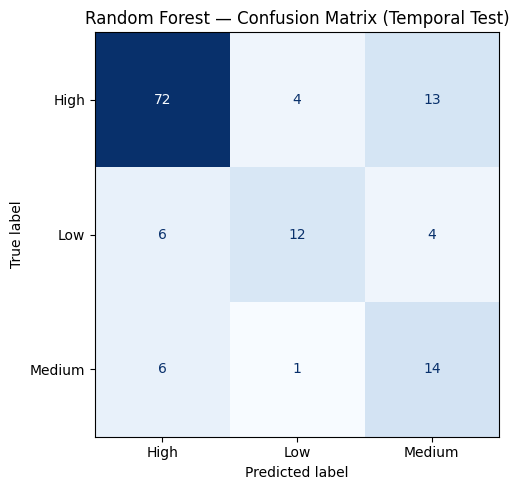

ROC-AUC (One-vs-Rest Macro): 0.8645


In [41]:
# Evaluating Random Forest on the Temporal Test Split

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)

print("=" * 55)
print("RANDOM FOREST — TEMPORAL TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=le.classes_
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix (Temporal Test)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'confusion_matrix_rf.png'), dpi=150)
plt.show()

roc_auc_rf = roc_auc_score(
    y_test, y_prob_rf, multi_class='ovr', average='macro')
print(f"ROC-AUC (One-vs-Rest Macro): {roc_auc_rf:.4f}")

In [42]:
# Evaluating Logistic Regression for Comaprison

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

print("=" * 55)
print("LOGISTIC REGRESSION — TEMPORAL TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

roc_auc_lr = roc_auc_score(
    y_test, y_prob_lr, multi_class='ovr', average='macro')
print(f"ROC-AUC (One-vs-Rest Macro): {roc_auc_lr:.4f}")

print("\n" + "=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<25} {'ROC-AUC':>10} {'CV F1 Mean':>12}")
print(f"{'Random Forest (tuned)':<25} {roc_auc_rf:>10.4f} "
      f"{cv_scores.mean():>12.4f}")
print(f"{'Logistic Regression':<25} {roc_auc_lr:>10.4f} {'N/A':>12}")

LOGISTIC REGRESSION — TEMPORAL TEST SET RESULTS
              precision    recall  f1-score   support

        High       0.77      0.55      0.64        89
         Low       0.22      0.68      0.33        22
      Medium       0.00      0.00      0.00        21

    accuracy                           0.48       132
   macro avg       0.33      0.41      0.32       132
weighted avg       0.55      0.48      0.49       132

ROC-AUC (One-vs-Rest Macro): 0.6237

MODEL COMPARISON SUMMARY
Model                        ROC-AUC   CV F1 Mean
Random Forest (tuned)         0.8645       0.8704
Logistic Regression           0.6237          N/A


In [43]:
# Gradient Boosting for comaprison

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

# Gradient Boosting with OneVsRest for multi-class support
gb = OneVsRestClassifier(
    GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
)
gb.fit(X_train_sm, y_train_sm)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)

print("=" * 55)
print("GRADIENT BOOSTING — TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

roc_auc_gb = roc_auc_score(
    y_test, y_prob_gb, multi_class='ovr', average='macro')
print(f"ROC-AUC (One-vs-Rest Macro): {roc_auc_gb:.4f}")

# Updating the comparison summary to include all three models
print("\n" + "=" * 55)
print("FULL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<25} {'ROC-AUC':>10} {'CV F1 Mean':>12}")
print(f"{'Random Forest (tuned)':<25} {roc_auc_rf:>10.4f} "
      f"{cv_scores.mean():>12.4f}")
print(f"{'Gradient Boosting':<25} {roc_auc_gb:>10.4f} {'N/A':>12}")
print(f"{'Logistic Regression':<25} {roc_auc_lr:>10.4f} {'N/A':>12}")
print("\nSelected model: Random Forest (tuned)")
print("Reason: Highest ROC-AUC, built-in feature importance,")
print("        compatible with SHAP explainability.")

GRADIENT BOOSTING — TEST SET RESULTS
              precision    recall  f1-score   support

        High       0.85      0.78      0.81        89
         Low       0.62      0.59      0.60        22
      Medium       0.40      0.57      0.47        21

    accuracy                           0.71       132
   macro avg       0.62      0.65      0.63       132
weighted avg       0.74      0.71      0.72       132

ROC-AUC (One-vs-Rest Macro): 0.8500

FULL MODEL COMPARISON SUMMARY
Model                        ROC-AUC   CV F1 Mean
Random Forest (tuned)         0.8645       0.8704
Gradient Boosting             0.8500          N/A
Logistic Regression           0.6237          N/A

Selected model: Random Forest (tuned)
Reason: Highest ROC-AUC, built-in feature importance,
        compatible with SHAP explainability.


All Feature Importances (ranked):
                 feature  importance
           invoice_count    0.221318
            recency_days    0.187644
   total_outstanding_usd    0.080677
   avg_invoice_value_usd    0.059143
       avg_invoice_value    0.053581
       total_sales_value    0.052619
         unique_products    0.043688
      relationship_years    0.040961
      purchase_frequency    0.038284
           active_months    0.031975
   has_unapplied_receipt    0.029072
  category_concentration    0.028357
       behaviour_cluster    0.028079
    unapplied_credit_abs    0.024714
       unique_categories    0.022815
           receipt_count    0.022177
receipt_to_invoice_ratio    0.019260
       credit_note_count    0.008567
        debit_note_count    0.003583
    total_debit_note_usd    0.003486


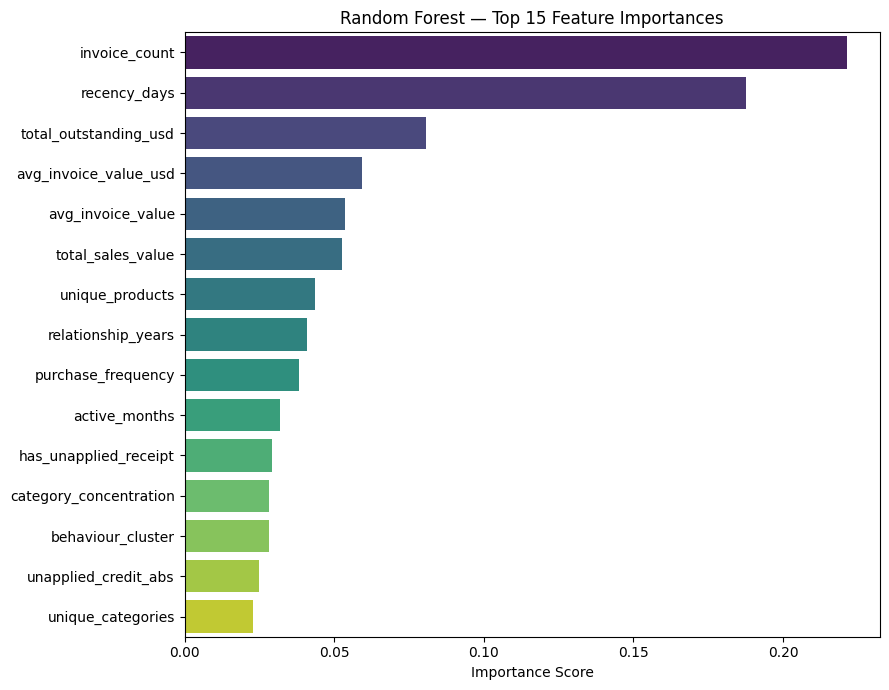

In [44]:
# Featuring Importance Plot

importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("All Feature Importances (ranked):")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=importance_df.head(15),
    x='importance', y='feature',
    palette='viridis', ax=ax
)
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'feature_importance.png'), dpi=150)
plt.show()

Computing SHAP values — this may take 2-3 minutes...


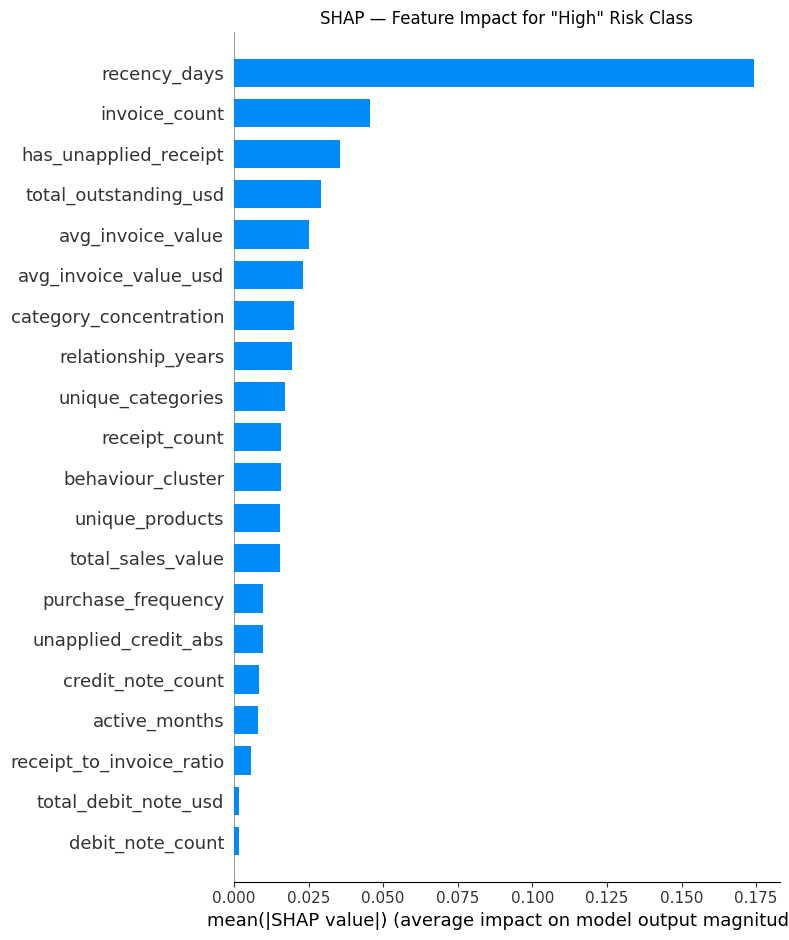

Saved: shap_summary_high.png


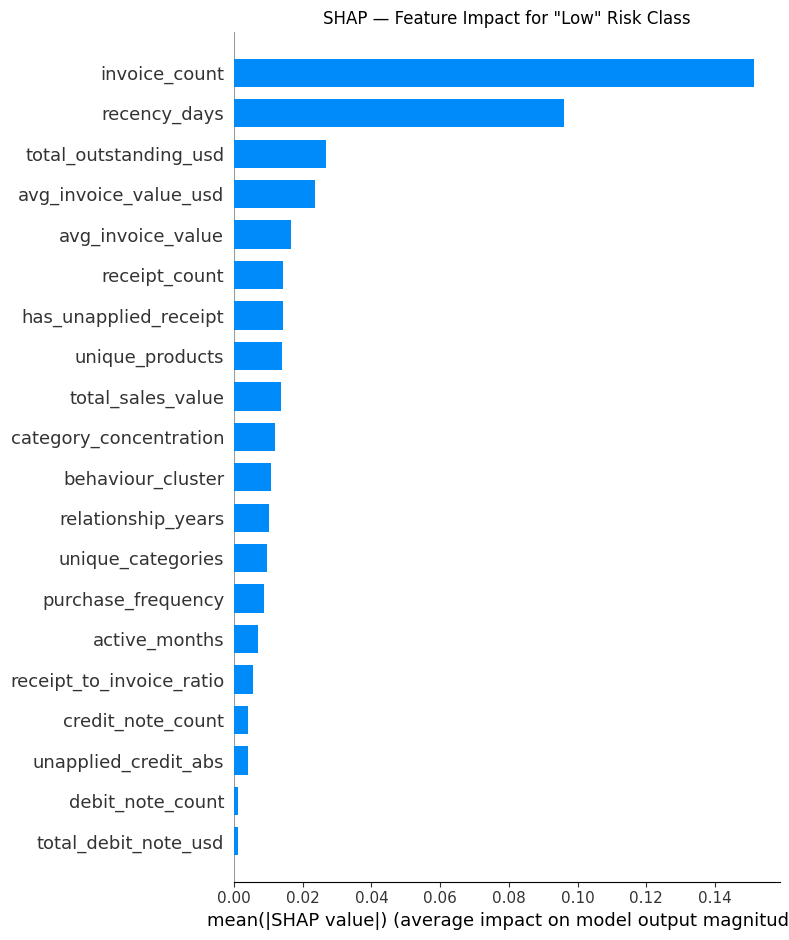

Saved: shap_summary_low.png


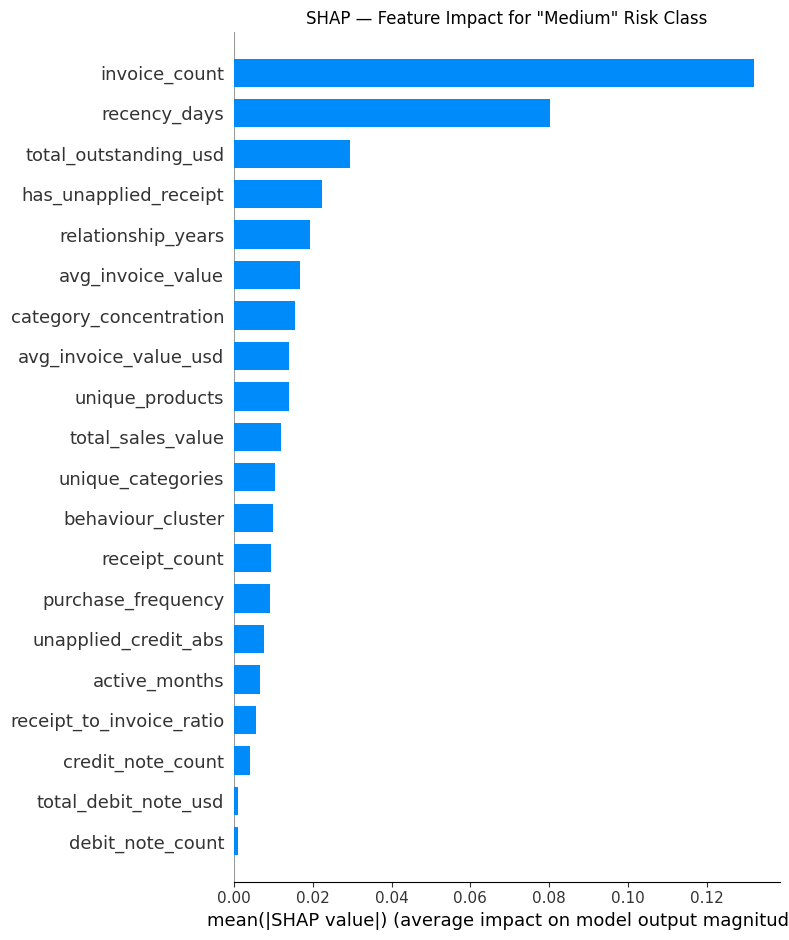

Saved: shap_summary_medium.png


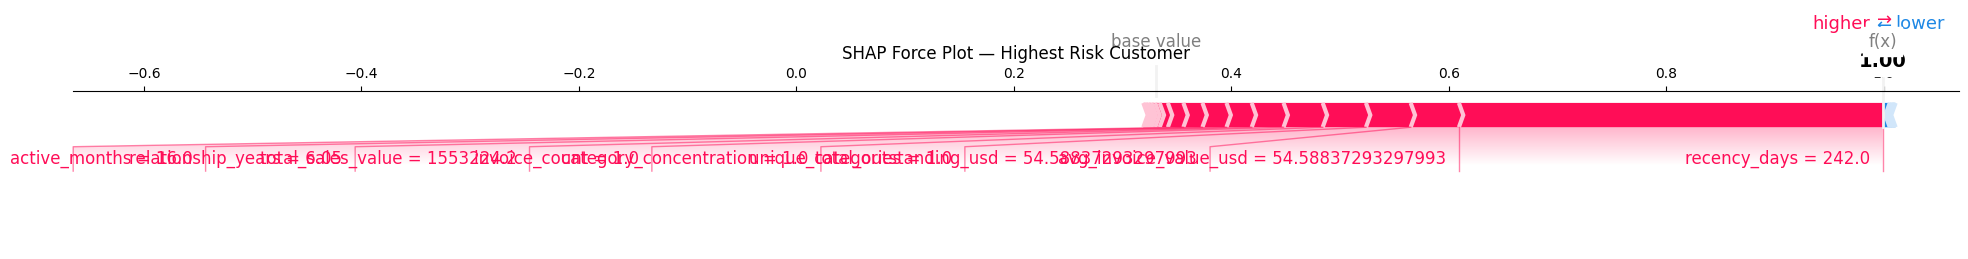

Saved: shap_force_top_customer.png
Saved: shap_values_all_customers.csv (656 customers)


In [45]:
# SHAP Explainability

print("Computing SHAP values — this may take 2-3 minutes...")
explainer = shap.TreeExplainer(best_rf)

X_all_shap = model_df_clean[feature_cols].values
shap_output_all = explainer(X_all_shap)

if hasattr(shap_output_all, 'values'):
    shap_array_all  = shap_output_all.values
    shap_values_all = [shap_array_all[:, :, i] for i in range(len(le.classes_))]
else:
    shap_values_all = shap_output_all

high_idx = list(le.classes_).index('High')

for i, class_name in enumerate(le.classes_):
    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        shap_values_all[i], X_all_shap,
        feature_names=feature_cols,
        show=False, plot_type='bar'
    )
    plt.title(f'SHAP — Feature Impact for "{class_name}" Risk Class')
    plt.tight_layout()
    plt.savefig(
        os.path.join(DATA_PROCESSED, f'shap_summary_{class_name.lower()}.png'),
        dpi=150)
    plt.show()
    print(f"Saved: shap_summary_{class_name.lower()}.png")

_y_prob_temp = best_rf.predict_proba(X_all_shap)
top_risk_idx = int(np.argmax(_y_prob_temp[:, high_idx]))

shap.force_plot(
    explainer.expected_value[high_idx],
    shap_values_all[high_idx][top_risk_idx],
    X_all_shap[top_risk_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Highest Risk Customer')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'shap_force_top_customer.png'), dpi=150)
plt.show()
print("Saved: shap_force_top_customer.png")

shap_export = pd.DataFrame(
    shap_values_all[high_idx],
    columns=[f'shap_{f}' for f in feature_cols]
)
shap_export['customerid'] = model_df_clean['customerid'].values
shap_export.to_csv(
    os.path.join(DATA_PROCESSED, 'shap_values_all_customers.csv'), index=False)
print(f"Saved: shap_values_all_customers.csv ({len(shap_export):,} customers)")

In [46]:
# Building the Risk Output Table

X_all      = model_df_clean[feature_cols].values
y_prob_all = best_rf.predict_proba(X_all)
y_pred_all = best_rf.predict(X_all)

high_idx_c   = list(le.classes_).index('High')
medium_idx_c = list(le.classes_).index('Medium')
low_idx_c    = list(le.classes_).index('Low')

final_risk_df = model_df_clean[['customerid', 'cuscode']].copy()

info_cols = ['customerid']
for col in ['customername', 'customer', 'country', 'term',
            'customerclassification', 'region']:
    if col in model_df_clean.columns:
        info_cols.append(col)

final_risk_df = final_risk_df.merge(
    model_df_clean[info_cols].drop_duplicates('customerid'),
    on='customerid', how='left'
)

final_risk_df['risk_band_predicted'] = le.inverse_transform(y_pred_all)
final_risk_df['prob_high']           = y_prob_all[:, high_idx_c].round(4)
final_risk_df['prob_medium']         = y_prob_all[:, medium_idx_c].round(4)
final_risk_df['prob_low']            = y_prob_all[:, low_idx_c].round(4)
final_risk_df['risk_score']          = (final_risk_df['prob_high'] * 100).round(1)

def risk_bucket(score):
    if score >= 70:   return 'High Risk'
    elif score >= 30: return 'Medium Risk'
    else:             return 'Low Risk'

final_risk_df['risk_bucket'] = final_risk_df['risk_score'].apply(risk_bucket)

_financial_cols = [
    'customerid',
    'total_outstanding_usd', 'total_outstanding_lkr',
    'max_overdue_days', 'avg_overdue_days',
    'invoice_count', 'receipt_count', 'debit_note_count', 'credit_note_count',
    'behaviour_cluster', 'cluster_name',
    'unique_products', 'unique_categories', 'top_category',
    'outstanding_0_30', 'outstanding_31_60',
    'outstanding_61_90', 'outstanding_91_plus',
]
_financial_cols = [c for c in _financial_cols if c in model_df_clean.columns]

final_risk_df = final_risk_df.merge(
    model_df_clean[_financial_cols],
    on='customerid', how='left'
)

_total = final_risk_df['total_outstanding_usd'].sum()
print("Final risk output shape:", final_risk_df.shape)
print("\nRisk bucket distribution:")
print(final_risk_df['risk_bucket'].value_counts())
print(f"\nOutstanding by risk tier:")
for bucket in ['High Risk', 'Medium Risk', 'Low Risk']:
    _amt = final_risk_df[final_risk_df['risk_bucket'] == bucket]['total_outstanding_usd'].sum()
    print(f"  {bucket:<14}: ${_amt:>12,.0f}  ({_amt/_total*100:.1f}%)")
print("\nTop 10 highest risk customers:")
print(
    final_risk_df.sort_values('risk_score', ascending=False)[[
        'cuscode', 'risk_score', 'risk_bucket',
        'total_outstanding_usd', 'max_overdue_days', 'top_category'
    ]].head(10).to_string(index=False)
)

Final risk output shape: (656, 27)

Risk bucket distribution:
risk_bucket
High Risk      332
Low Risk       169
Medium Risk    155
Name: count, dtype: int64

Outstanding by risk tier:
  High Risk     : $  14,065,365  (49.0%)
  Medium Risk   : $   3,584,080  (12.5%)
  Low Risk      : $  11,045,297  (38.5%)

Top 10 highest risk customers:
cuscode  risk_score risk_bucket  total_outstanding_usd  max_overdue_days top_category
  10594        99.9   High Risk              54.588373               142       GLOBAL
  12131        99.1   High Risk              89.639734                23       GLOBAL
  10507        98.9   High Risk              56.788904                46       GLOBAL
  12374        98.8   High Risk               0.068625               221       GLOBAL
  12677        98.7   High Risk             808.575243                30       GLOBAL
  12664        98.5   High Risk             724.934307                63       GLOBAL
  12678        98.4   High Risk             530.259834     

In [47]:
# Cross Tabulating Clsuters vs Risk Buckets
# Shows how credit risk is distributed across each customer segment. 

crosstab = pd.crosstab(
    final_risk_df['cluster_name'],
    final_risk_df['risk_bucket'],
    normalize='index'
).round(2)

print("Proportion of each risk bucket within each customer segment:")
display(crosstab)

print("\nProduct diversity by risk bucket (mean values):")
print(
    final_risk_df.groupby('risk_bucket')[[
        'unique_products', 'unique_categories'
    ]].mean().round(1).to_string()
)

Proportion of each risk bucket within each customer segment:


risk_bucket,High Risk,Low Risk,Medium Risk
cluster_name,,,
Churned / Inactive,1.00,0.00,0.00
High Frequency Buyers,0.58,0.22,0.20
High Value One-Off,0.48,0.26,0.26
Loyal Medium Buyers,0.71,0.21,0.07
No Sales History,0.70,0.16,0.14
Strategic High-Value,0.43,0.31,0.26



Product diversity by risk bucket (mean values):
             unique_products  unique_categories
risk_bucket                                    
High Risk               52.7                1.5
Low Risk                33.2                1.6
Medium Risk             40.0                1.7


In [48]:
# Saving Everything

final_risk_df.to_csv(
    os.path.join(DATA_PROCESSED, 'final_risk_output.csv'), index=False)
model_df_clean.to_csv(
    os.path.join(DATA_PROCESSED, 'master_features.csv'), index=False)
behaviour_df.to_csv(
    os.path.join(DATA_PROCESSED, 'behaviour_clusters.csv'), index=False)

joblib.dump(best_rf,      os.path.join(MODEL_ARTIFACTS, 'rf_risk_band_model.pkl'))
joblib.dump(le,           os.path.join(MODEL_ARTIFACTS, 'risk_band_label_encoder.pkl'))
joblib.dump(feature_cols, os.path.join(MODEL_ARTIFACTS, 'feature_columns.pkl'))
joblib.dump(explainer,    os.path.join(MODEL_ARTIFACTS, 'shap_explainer.pkl'))
joblib.dump(scaler,       os.path.join(MODEL_ARTIFACTS, 'behaviour_scaler.pkl'))
joblib.dump(kmeans_final, os.path.join(MODEL_ARTIFACTS, 'kmeans_model.pkl'))

_high = final_risk_df[final_risk_df['risk_bucket'] == 'High Risk']
_med  = final_risk_df[final_risk_df['risk_bucket'] == 'Medium Risk']
_low  = final_risk_df[final_risk_df['risk_bucket'] == 'Low Risk']

kpi = {
    'total_customers'             : int(len(final_risk_df)),
    'high_risk_count'             : int(len(_high)),
    'medium_risk_count'           : int(len(_med)),
    'low_risk_count'              : int(len(_low)),
    'total_outstanding_usd'       : float(final_risk_df['total_outstanding_usd'].sum()),
    'total_outstanding_lkr'       : float(model_df_clean['total_outstanding_lkr'].sum()),
    'high_risk_outstanding_usd'   : float(_high['total_outstanding_usd'].sum()),
    'high_risk_outstanding_lkr'   : float(
        _high['total_outstanding_lkr'].sum()
        if 'total_outstanding_lkr' in _high.columns else 0),
    'medium_risk_outstanding_usd' : float(_med['total_outstanding_usd'].sum()),
    'low_risk_outstanding_usd'    : float(_low['total_outstanding_usd'].sum()),
    'avg_overdue_days'            : float(final_risk_df['avg_overdue_days'].mean()),
    'data_as_of'                  : str(pd.to_datetime(invoices['docdate']).max().date()),
    'model_roc_auc'               : round(float(roc_auc_rf), 4),
    'model_cv_f1_mean'            : round(float(cv_scores.mean()), 4),
    'model_cv_f1_std'             : round(float(cv_scores.std()), 4),
    'model_features_count'        : len(feature_cols),
    'shap_file'                   : 'shap_values_all_customers.csv',
}

with open(os.path.join(DATA_PROCESSED, 'kpi_summary.json'), 'w') as f:
    json.dump(kpi, f, indent=2)

print("All outputs saved successfully.")
print(f"\nKPI Summary:")
for k, v in kpi.items():
    print(f"  {k:<35}: {v}")
print(f"\nFiles in data_processed/:")
for fname in sorted(os.listdir(DATA_PROCESSED)):
    print(f"  {fname}")
print(f"\nFiles in model_artifacts/:")
for fname in sorted(os.listdir(MODEL_ARTIFACTS)):
    print(f"  {fname}")

All outputs saved successfully.

KPI Summary:
  total_customers                    : 656
  high_risk_count                    : 332
  medium_risk_count                  : 155
  low_risk_count                     : 169
  total_outstanding_usd              : 28694741.596007466
  total_outstanding_lkr              : 8263754853.6
  high_risk_outstanding_usd          : 14065365.222635845
  high_risk_outstanding_lkr          : 3908523994.3
  medium_risk_outstanding_usd        : 3584079.7163581382
  low_risk_outstanding_usd           : 11045296.657013483
  avg_overdue_days                   : 182.25773926257574
  data_as_of                         : 2025-10-11
  model_roc_auc                      : 0.8645
  model_cv_f1_mean                   : 0.8704
  model_cv_f1_std                    : 0.0626
  model_features_count               : 20
  shap_file                          : shap_values_all_customers.csv

Files in data_processed/:
  behaviour_clusters.csv
  cluster_pca_plot.png
  confusion_ma

In [49]:
# Summary

print("=" * 62)
print("   DEBTOR RISK MANAGEMENT — FINAL MODEL SUMMARY")
print("=" * 62)
print(f"\n  Dataset")
print(f"    Total customers        : {len(final_risk_df):,}")
print(f"    Total features         : {len(feature_cols)}")
print(f"\n  Model")
print(f"    Algorithm              : Random Forest")
print(f"    Tuning                 : GridSearchCV (5-fold CV)")
print(f"    Class balancing        : SMOTE + class_weight='balanced'")
print(f"    Best params            : {grid_search.best_params_}")
print(f"\n  Performance")
print(f"    CV F1 Macro            : "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"    ROC-AUC (OvR Macro)    : {roc_auc_rf:.4f}")
print(f"\n  Risk Distribution")
for label, count in final_risk_df['risk_bucket'].value_counts().items():
    pct = count / len(final_risk_df) * 100
    print(f"    {label:<18} : {count:>4} customers ({pct:.1f}%)")
print(f"\n  Financial Exposure")
total_usd = final_risk_df['total_outstanding_usd'].sum()
high_usd  = final_risk_df[
    final_risk_df['risk_bucket'] == 'High Risk'][
    'total_outstanding_usd'].sum()
print(f"    Total Outstanding USD  : ${total_usd:>14,.0f}")
print(f"    High Risk Exposure USD : ${high_usd:>14,.0f}")
print(f"    High Risk % of Total   : "
      f"{high_usd / total_usd * 100:.1f}%")
print("=" * 62)

   DEBTOR RISK MANAGEMENT — FINAL MODEL SUMMARY

  Dataset
    Total customers        : 656
    Total features         : 20

  Model
    Algorithm              : Random Forest
    Tuning                 : GridSearchCV (5-fold CV)
    Class balancing        : SMOTE + class_weight='balanced'
    Best params            : {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

  Performance
    CV F1 Macro            : 0.8704 ± 0.0626
    ROC-AUC (OvR Macro)    : 0.8645

  Risk Distribution
    High Risk          :  332 customers (50.6%)
    Low Risk           :  169 customers (25.8%)
    Medium Risk        :  155 customers (23.6%)

  Financial Exposure
    Total Outstanding USD  : $    28,694,742
    High Risk Exposure USD : $    14,065,365
    High Risk % of Total   : 49.0%


In [55]:
# Data Validation

print("=" * 60)
print("1. RAW DATA — NULL CHECKS")
print("=" * 60)

critical_cols_outstanding = ['customerid', 'cuscode', 'docid', 'document_type',
                              'outstandingusd', 'overduedurationdays', 'docdate']
critical_cols_sales       = ['customerid', SALES_VALUE_COL, 'invoicedate']
critical_cols_master      = ['customerid']

for label, df, cols in [
    ('Customer Outstanding', outstanding_raw, critical_cols_outstanding),
    ('Sales Master',         sales_raw,       critical_cols_sales),
    ('Customer Master',      customer_master, critical_cols_master),
]:
    nulls = df[cols].isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"  {label}: No nulls in critical columns ✓")
    else:
        print(f"  {label}: Nulls found —")
        print(nulls.to_string())

print()
print("=" * 60)
print("2. RAW DATA — DUPLICATE CHECKS")
print("=" * 60)

dup_invoices  = outstanding_raw['docid'].duplicated().sum()
dup_customers = customer_master['customerid'].duplicated().sum()
dup_sales     = sales_raw.duplicated().sum()

print(f"  Duplicate DOCID in outstanding   : {dup_invoices}")
print(f"  Duplicate CustomerID in master   : {dup_customers}")
print(f"  Duplicate rows in sales          : {dup_sales}")

print()
print("=" * 60)
print("3. RANGE & OUTLIER VALIDATION")
print("=" * 60)

neg_outstanding = (outstanding_raw['outstandingusd'] < 0).sum()
neg_overdue     = (outstanding_raw['overduedurationdays'] < 0).sum()
extreme_overdue = (outstanding_raw['overduedurationdays'] > 3000).sum()
null_dates      = outstanding_raw['docdate'].isnull().sum()

date_min = outstanding_raw['docdate'].min()
date_max = outstanding_raw['docdate'].max()

print(f"  Negative outstanding USD         : {neg_outstanding}")
print(f"  Negative overdue days            : {neg_overdue}")
print(f"  Overdue days > 3000 (extreme)    : {extreme_overdue}")
print(f"  Null dates after conversion      : {null_dates}")
print(f"  Date range                       : {date_min} → {date_max}")

if SALES_VALUE_COL:
    neg_sales = (sales_raw[SALES_VALUE_COL] < 0).sum()
    print(f"  Negative sales values            : {neg_sales}")

print()
print("=" * 60)
print("4. ERP MIGRATION ENTRIES REMOVED")
print("=" * 60)

migration_check = (
    (outstanding_raw['docdate'].dt.date == pd.Timestamp('2021-03-05').date()) &
    (outstanding_raw['overduedurationdays'] == 1656)
).sum()
wo_check = (
    (outstanding_raw['document_type'] == 'debit_note') &
    (outstanding_raw['refno'].astype(str).str.strip().str.upper() == 'WO')
).sum()

rows_removed = len(outstanding_raw) - len(debtor_df)

print(f"  Migration entries in raw data    : {migration_check}")
print(f"  Write-off debit notes in raw     : {wo_check}")
print(f"  Total rows removed after clean   : {rows_removed}")
print(f"  Rows before                      : {len(outstanding_raw):,}")
print(f"  Rows after                       : {len(debtor_df):,}")

print()
print("=" * 60)
print("5. DOCUMENT TYPE SPLIT RECONCILIATION")
print("=" * 60)

total_split = len(invoices) + len(receipts) + len(debit_notes) + len(credit_notes)
other_types = len(debtor_df) - total_split

print(f"  Invoices                         : {len(invoices):,}")
print(f"  Receipts                         : {len(receipts):,}")
print(f"  Debit Notes                      : {len(debit_notes):,}")
print(f"  Credit Notes                     : {len(credit_notes):,}")
print(f"  Total accounted for              : {total_split:,}")
print(f"  Unclassified rows                : {other_types}")
print(f"  Source rows (debtor_df)          : {len(debtor_df):,}")
if other_types == 0:
    print("  All rows accounted for ✓")

print()
print("=" * 60)
print("6. CUSTOMER COUNT RECONCILIATION")
print("=" * 60)

customers_in_outstanding = debtor_df['customerid'].nunique()
customers_in_master      = customer_master['customerid'].nunique()
customers_in_invoices    = invoices['customerid'].nunique()
customers_in_sales       = sales_raw['customerid'].nunique() if 'customerid' in sales_raw.columns else 'N/A'
customers_in_model       = len(model_df_clean)
customers_in_output      = len(final_risk_df)

print(f"  Customers in outstanding data    : {customers_in_outstanding:,}")
print(f"  Customers in master file         : {customers_in_master:,}")
print(f"  Customers with invoices          : {customers_in_invoices:,}")
print(f"  Customers in sales data          : {customers_in_sales}")
print(f"  Customers in model (after clean) : {customers_in_model:,}")
print(f"  Customers in final risk output   : {customers_in_output:,}")

print()
print("=" * 60)
print("7. FEATURE ENGINEERING VALIDATION")
print("=" * 60)

debtor_feature_cols = [
    'invoice_count', 'avg_invoice_value_usd', 'total_outstanding_usd',
    'receipt_count', 'unapplied_credit_abs', 'has_unapplied_receipt',
    'receipt_to_invoice_ratio', 'debit_note_count', 'total_debit_note_usd',
    'credit_note_count',
]
sales_feature_cols = [
    'total_sales_value', 'avg_invoice_value', 'active_months', 'recency_days',
    'purchase_frequency', 'relationship_years', 'unique_products',
    'unique_categories', 'category_concentration', 'behaviour_cluster',
]

print("  Debtor features in master_debtor:")
nulls_debtor = master_debtor[debtor_feature_cols].isnull().sum()
nulls_debtor = nulls_debtor[nulls_debtor > 0]
if nulls_debtor.empty:
    print("    No nulls ✓")
else:
    print(nulls_debtor.to_string())

print("  Sales/behaviour features in model_df_clean:")
nulls_sales = model_df_clean[sales_feature_cols].isnull().sum()
nulls_sales = nulls_sales[nulls_sales > 0]
if nulls_sales.empty:
    print("    No nulls ✓")
else:
    print(nulls_sales.to_string())

print("  All 20 features in model_df_clean:")
nulls_all = model_df_clean[feature_cols].isnull().sum()
nulls_all = nulls_all[nulls_all > 0]
if nulls_all.empty:
    print("    No nulls ✓")
else:
    print(nulls_all.to_string())

pct_check   = ((model_df_clean['pct_overdue_invoices'] < 0) |
               (model_df_clean['pct_overdue_invoices'] > 1)).sum()
ratio_check = (model_df_clean['receipt_to_invoice_ratio'] < 0).sum()
rec_check   = (model_df_clean['recency_days'] < 0).sum()

print(f"  pct_overdue_invoices out of [0,1]: {pct_check}")
print(f"  Negative receipt_to_invoice_ratio: {ratio_check}")
print(f"  Negative recency_days            : {rec_check}")

print()
print("=" * 60)
print("8. FINAL OUTPUT VALIDATION")
print("=" * 60)

nulls_output = final_risk_df[['risk_score', 'risk_bucket',
                               'prob_high', 'prob_medium', 'prob_low']].isnull().sum()
prob_sum     = (final_risk_df['prob_high'] +
                final_risk_df['prob_medium'] +
                final_risk_df['prob_low'])
prob_sum_check = ((prob_sum < 0.999) | (prob_sum > 1.001)).sum()
score_range    = ((final_risk_df['risk_score'] < 0) |
                  (final_risk_df['risk_score'] > 100)).sum()
dup_output     = final_risk_df['customerid'].duplicated().sum()

print(f"  Nulls in risk output columns     : {nulls_output.sum()}")
print(f"  Probabilities not summing to 1   : {prob_sum_check}")
print(f"  Risk scores outside [0, 100]     : {score_range}")
print(f"  Duplicate customers in output    : {dup_output}")
print()
print(f"  Risk bucket distribution:")
print(final_risk_df['risk_bucket'].value_counts().to_string())
print()
print(f"  Outstanding totals by bucket (USD):")
print(final_risk_df.groupby('risk_bucket')['total_outstanding_usd']
      .sum().apply(lambda x: f"${x:,.0f}").to_string())
print()
print(f"  Aging bucket totals (USD):")
for col in ['outstanding_0_30', 'outstanding_31_60',
            'outstanding_61_90', 'outstanding_91_plus']:
    if col in final_risk_df.columns:
        print(f"    {col:<28}: ${final_risk_df[col].sum():>12,.0f}")

aging_total       = final_risk_df[['outstanding_0_30', 'outstanding_31_60',
                                    'outstanding_61_90', 'outstanding_91_plus']].sum().sum()
outstanding_total = final_risk_df['total_outstanding_usd'].sum()
print(f"\n  Aging buckets sum                : ${aging_total:>12,.0f}")
print(f"  total_outstanding_usd sum        : ${outstanding_total:>12,.0f}")
if abs(aging_total - outstanding_total) / outstanding_total < 0.01:
    print("  Aging buckets reconcile with total outstanding ✓")
else:
    print(f"  WARNING: Difference of ${abs(aging_total - outstanding_total):,.0f}")

print()
print("=" * 60)
print("9. SHAP OUTPUT VALIDATION")
print("=" * 60)

shap_path  = os.path.join(DATA_PROCESSED, 'shap_values_all_customers.csv')
shap_check = pd.read_csv(shap_path)
shap_cols  = [c for c in shap_check.columns if c.startswith('shap_')]

print(f"  SHAP file rows                   : {len(shap_check):,}")
print(f"  SHAP features                    : {len(shap_cols)}")
print(f"  Expected customers               : {len(final_risk_df):,}")
print(f"  All customers covered            : {len(shap_check) == len(final_risk_df)}")
nulls_shap = shap_check[shap_cols].isnull().sum().sum()
print(f"  Null SHAP values                 : {nulls_shap}")

print()
print("=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

1. RAW DATA — NULL CHECKS
  Customer Outstanding: Nulls found —
outstandingusd    40
  Sales Master: No nulls in critical columns ✓
  Customer Master: No nulls in critical columns ✓

2. RAW DATA — DUPLICATE CHECKS
  Duplicate DOCID in outstanding   : 8
  Duplicate CustomerID in master   : 0
  Duplicate rows in sales          : 3

3. RANGE & OUTLIER VALIDATION
  Negative outstanding USD         : 826
  Negative overdue days            : 0
  Overdue days > 3000 (extreme)    : 14
  Null dates after conversion      : 0
  Date range                       : 2012-02-08 00:00:00 → 2025-10-11 00:00:00
  Negative sales values            : 9563

4. ERP MIGRATION ENTRIES REMOVED
  Migration entries in raw data    : 0
  Write-off debit notes in raw     : 2
  Total rows removed after clean   : 2
  Rows before                      : 6,306
  Rows after                       : 6,304

5. DOCUMENT TYPE SPLIT RECONCILIATION
  Invoices                         : 5,334
  Receipts                         : 77

In [50]:
import sklearn
import sys
print("Python:", sys.executable)
print("sklearn version:", sklearn.__version__)

Python: c:\Users\Shamendry\AppData\Local\Programs\Python\Python312\python.exe
sklearn version: 1.8.0


In [51]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import sklearn
import sys
print("Python:", sys.executable)
print("sklearn version:", sklearn.__version__)

Python: c:\Users\Shamendry\AppData\Local\Programs\Python\Python312\python.exe
sklearn version: 1.8.0


In [53]:
pip install shap

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: shap in c:\users\shamendry\appdata\local\programs\python\python312\lib\site-packages (0.51.0)




[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
